In [5]:
import astropy.table as at
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import thejoker as tj
from astropy.time import Time
from astropy.visualization.units import quantity_support

%matplotlib inline

In [7]:
# set up a random generator to ensure reproducibility
rnd = np.random.default_rng(seed=42)

In [8]:
data_tbl = at.QTable.read("data.ecsv")
data_tbl[:2]

bjd,rv,rv_err
,km / s,km / s
float64,float64,float64
2458511.7951135524,37.63538635612137,0.22341820389458492
2458512.1973919393,37.79438880018236,0.48399198155187484


In [9]:
sub_tbl = data_tbl[rnd.choice(len(data_tbl), size=4, replace=False)]

In [10]:
sub_tbl

bjd,rv,rv_err
,km / s,km / s
float64,float64,float64
2458565.460461512,31.529043638289064,0.2501522105202238
2458522.979423407,31.929742318719594,0.14095428238633567
2458591.1628828607,34.4158358428304,0.31413876399455787
2458608.302156811,30.694920595662715,0.13790075427094659


In [11]:
t = Time(sub_tbl["bjd"], format="jd", scale="tcb")
data = tj.RVData(t=t, rv=sub_tbl["rv"], rv_err=sub_tbl["rv_err"])

In [12]:
data = tj.RVData.guess_from_table(sub_tbl)

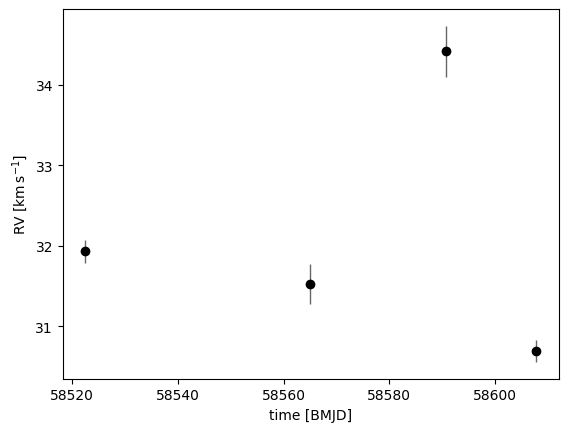

In [13]:
_ = data.plot()

In [14]:
prior = tj.JokerPrior.default(
    P_min=2 * u.day,
    P_max=1e3 * u.day,
    sigma_K0=30 * u.km / u.s,
    sigma_v=100 * u.km / u.s,
)

In [15]:
prior_samples = prior.sample(size=250_000, rng=rnd)
prior_samples

<JokerSamples [e, omega, M0, s, P] (250000 samples)>

In [16]:
prior_samples["P"]

<Quantity [  3.22306952, 414.47411357, 565.0750208 , ..., 174.64901845,
            14.08221517,   2.42661603] d>

In [17]:
prior_samples["e"]

<Quantity [0.02613975, 0.2823143 , 0.05891811, ..., 0.12625133, 0.11314765,
           0.14098373]>

In [18]:
prior_samples.write("prior_samples.hdf5", overwrite=True)

In [19]:
tj.JokerSamples.read("prior_samples.hdf5")

<JokerSamples [e, omega, M0, s, P] (250000 samples)>

In [20]:
joker = tj.TheJoker(prior, rng=rnd)
joker_samples = joker.rejection_sample(data, prior_samples, max_posterior_samples=256)

In [21]:
joker_samples = joker.rejection_sample(
    data, "prior_samples.hdf5", max_posterior_samples=256
)

In [22]:
joker_samples

<JokerSamples [P, e, omega, M0, s, K, v0] (82 samples)>

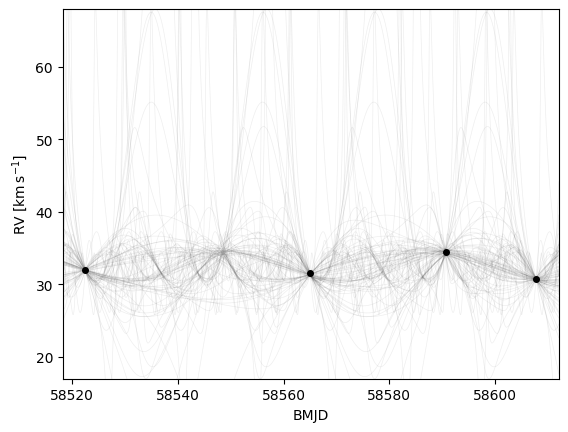

In [23]:
_ = tj.plot_rv_curves(joker_samples, data=data)

Text(0.5, 0, 'BMJD$ - 58522.479$')

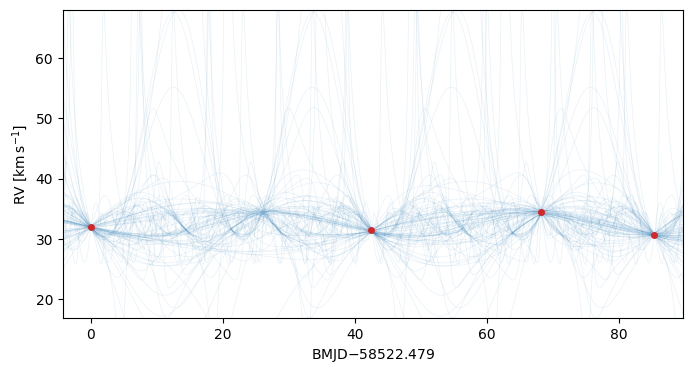

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
_ = tj.plot_rv_curves(
    joker_samples,
    data=data,
    plot_kwargs=dict(color="tab:blue"),
    data_plot_kwargs=dict(color="tab:red"),
    relative_to_t_ref=True,
    ax=ax,
)
ax.set_xlabel(f"BMJD$ - {data.t.tcb.mjd.min():.3f}$")

Text(0, 0.5, '$e$')

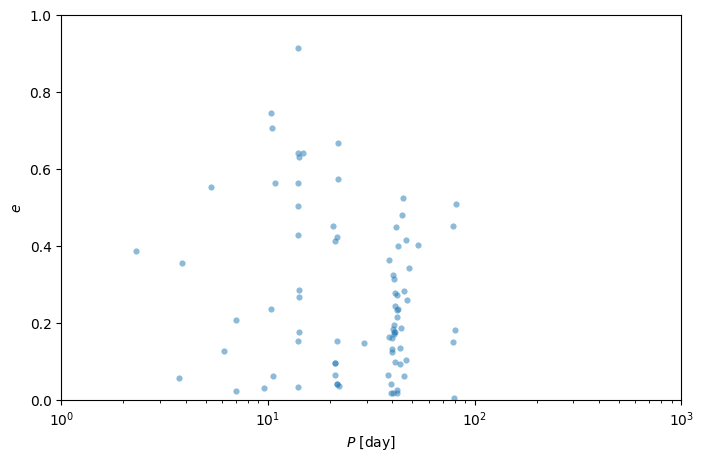

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

with quantity_support():
    ax.scatter(joker_samples["P"], joker_samples["e"], s=20, lw=0, alpha=0.5)

ax.set_xscale("log")
ax.set_xlim(1, 1e3)
ax.set_ylim(0, 1)

ax.set_xlabel("$P$ [day]")
ax.set_ylabel("$e$")

In [26]:
import pickle

with open("true-orbit.pkl", "rb") as f:
    truth = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'true-orbit.pkl'